In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv("../data/processed/customers.csv")

df.head()

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency
0,12346.0,1,77183.60,2011-01-18 10:01:00,325
1,12347.0,7,4310.00,2011-12-07 15:52:00,1
2,12348.0,4,1797.24,2011-09-25 13:13:00,74
3,12349.0,1,1757.55,2011-11-21 09:51:00,18
4,12350.0,1,334.40,2011-02-02 16:01:00,309


In [13]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        4338 non-null   float64
 1   Frequency         4338 non-null   int64  
 2   Monetary          4338 non-null   float64
 3   LastPurchaseDate  4338 non-null   str    
 4   Recency           4338 non-null   int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 169.6 KB


,CustomerID,Frequency,Monetary,Recency
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,4.272015,2048.688081,91.536422
std,1721.808492,7.697998,8985.230220,100.014169
min,12346.000000,1.000000,3.750000,0.000000
25%,13813.250000,1.000000,306.482500,17.000000
50%,15299.500000,2.000000,668.570000,50.000000
75%,16778.750000,5.000000,1660.597500,141.000000
max,18287.000000,209.000000,280206.020000,373.000000


In [16]:
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'])

print("min :", df['LastPurchaseDate'].min())
print("max :", df['LastPurchaseDate'].max())
print("total :", df['LastPurchaseDate'].max() - df['LastPurchaseDate'].min())
print("Years:", round((df['LastPurchaseDate'].max() - df['LastPurchaseDate'].min()).days / 365, 1))

min : 2010-12-01 09:53:00
max : 2011-12-09 12:50:00
total : 373 days 02:57:00
Years: 1.0


In [17]:
# Average Order Value
df['Average_Order_Value'] = df['Monetary'] / df['Frequency']

features = ['Recency', 'Frequency', 'Monetary', 'Average_Order_Value']

print(df[features].describe().round(2))

       Recency  Frequency   Monetary  Average_Order_Value
count  4338.00    4338.00    4338.00              4338.00
mean     91.54       4.27    2048.69               417.65
std     100.01       7.70    8985.23              1796.51
min       0.00       1.00       3.75                 3.45
25%      17.00       1.00     306.48               177.87
50%      50.00       2.00     668.57               291.94
75%     141.00       5.00    1660.60               428.28
max     373.00     209.00  280206.02             84236.25


## The dataset shows outliers, especially in Monetary and Average Order Value,
indicating the presence of high-value customers. Since K-Means is distance-based,
scaling will be applied to prevent these extreme values from dominating the clustering process.

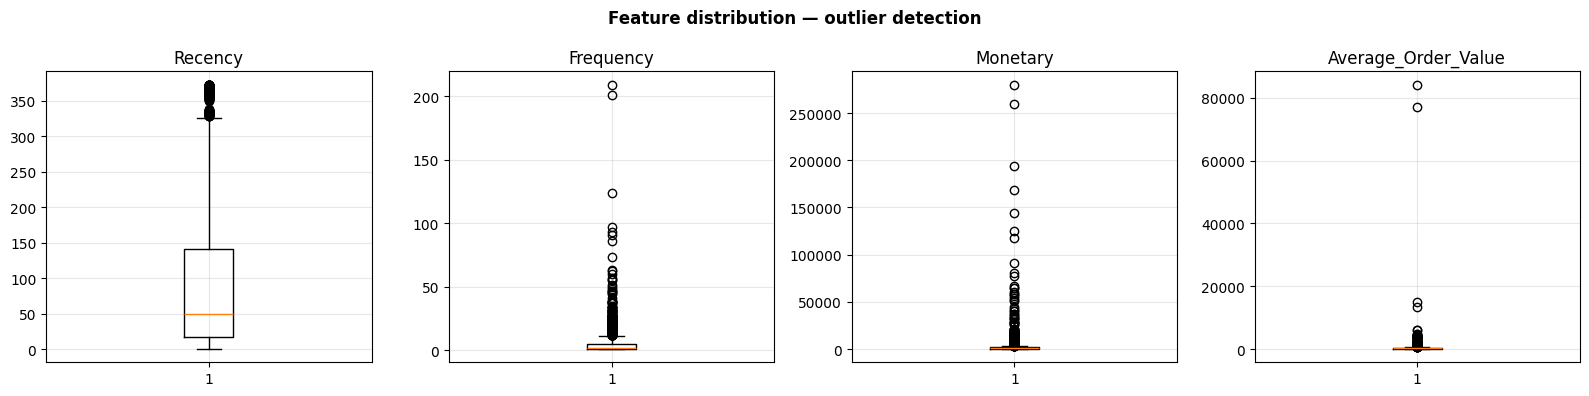

In [19]:
# View outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].grid(True, alpha=0.3)
plt.suptitle("Feature distribution — outlier detection", fontweight='bold')
plt.tight_layout()
plt.show()

## We apply a logarithmic transformation to reduce the impact of outliers without removing high-value customers,
who are important from a business perspective. Next, we apply a StandardScaler to bring all variables onto a comparable scale before using K-Means.

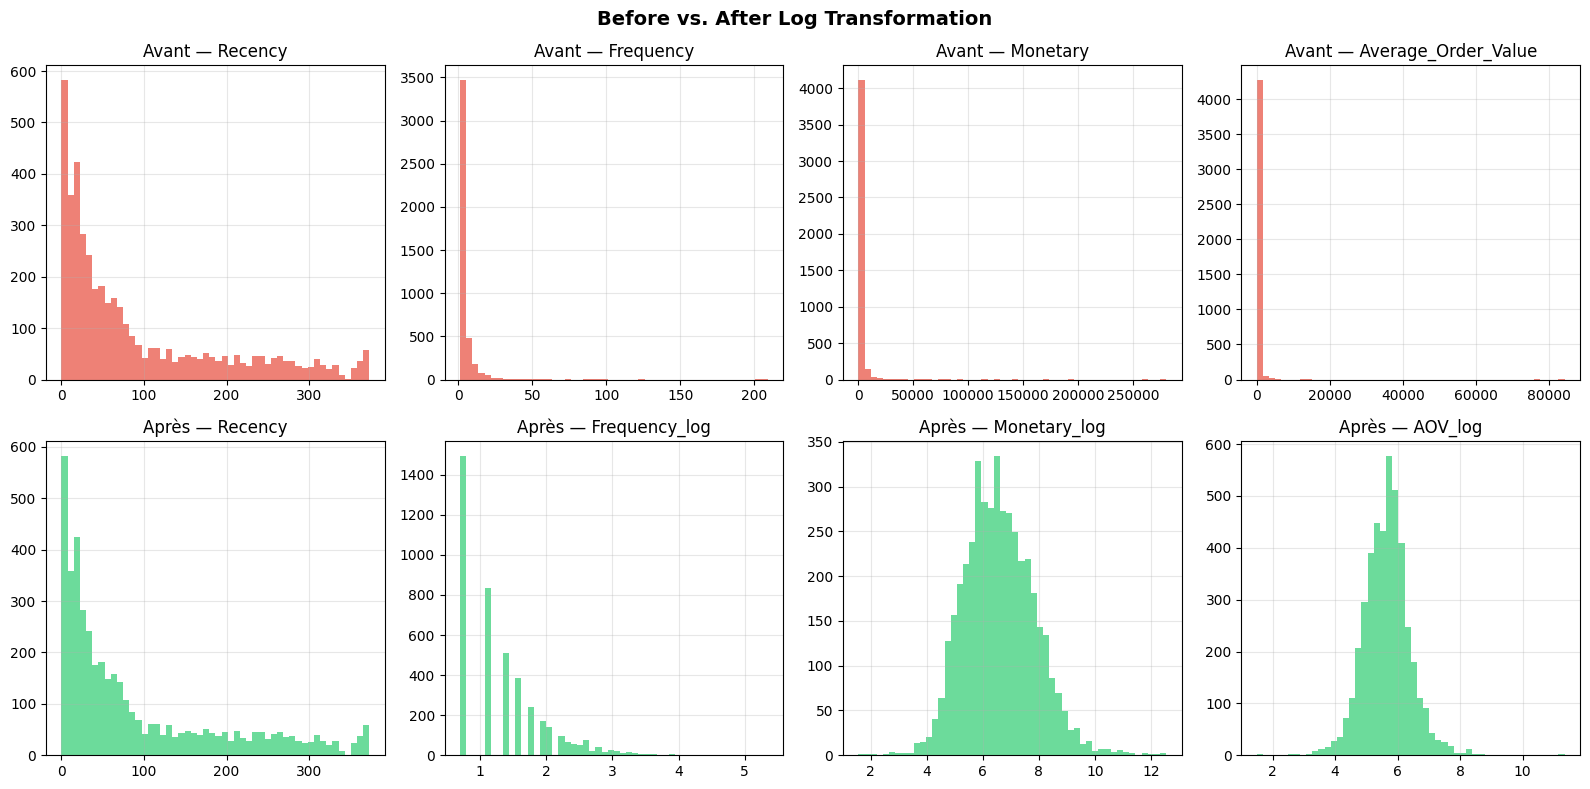

In [24]:
# Log Transformation
df['Monetary_log'] = np.log1p(df['Monetary'])
df['Frequency_log'] = np.log1p(df['Frequency'])
df['AOV_log'] = np.log1p(df['Average_Order_Value'])

features = ['Recency', 'Frequency_log', 'Monetary_log', 'AOV_log']

# Check the distribution after processing
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

original = ['Recency', 'Frequency', 'Monetary', 'Average_Order_Value']
transformed = ['Recency', 'Frequency_log', 'Monetary_log', 'AOV_log']

for i, (orig, trans) in enumerate(zip(original, transformed)):
    axes[0, i].hist(df[orig], bins=50, color='#E74C3C', alpha=0.7)
    axes[0, i].set_title(f'Avant — {orig}')
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].hist(df[trans], bins=50, color='#2ECC71', alpha=0.7)
    axes[1, i].set_title(f'Après — {trans}')
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle("Before vs. After Log Transformation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scaling
X = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

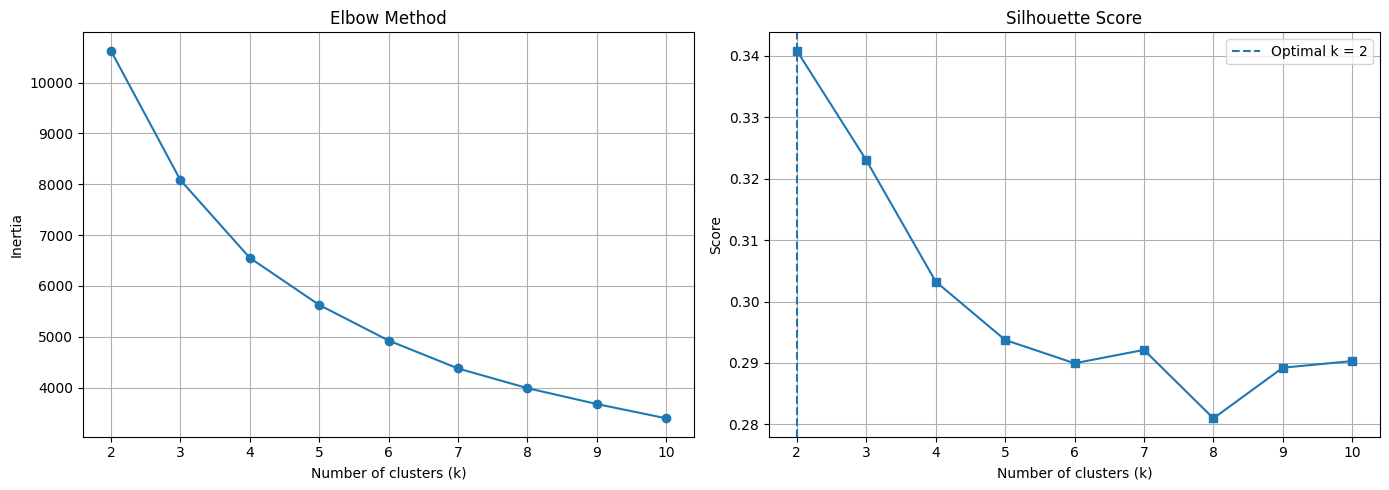

Optimal number of clusters (k) = 2


In [28]:
from sklearn.metrics import silhouette_score

# Initialize lists to store metrics
inertias = []
silhouettes = []

# Range of k values to test
K_range = range(2, 11)

for k in K_range:
    # Initialize KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Fit model
    km.fit(X_scaled)
    
    # Store inertia (Elbow Method)
    inertias.append(km.inertia_)
    
    # Compute silhouette score
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

# Silhouette plot
axes[1].plot(K_range, silhouettes, marker='s')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score")
axes[1].grid(True)

# Best k based on silhouette score
best_k = K_range[np.argmax(silhouettes)]

# Highlight best k
axes[1].axvline(x=best_k, linestyle='--', label=f'Optimal k = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Optimal number of clusters (k) = {best_k}")

## Although the Silhouette Score suggests 2 clusters, 
this solution is too simplistic from a business perspective.
Based on the Elbow Method and interpretability considerations,
we selected 3 or 4 clusters to obtain a more meaningful customer segmentation.

In [30]:
# Final KMeans model
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

summary = df.groupby('Cluster').agg(
    Count=('Recency','count'),
    Recency_mean=('Recency','mean'),
    Frequency_mean=('Frequency','mean'),
    Monetary_mean=('Monetary','mean'),
     AOV_mean=('Average_Order_Value','mean'),
).round(1)

print(summary)

         Count  Recency_mean  Frequency_mean  Monetary_mean  AOV_mean
Cluster                                                              
0         1010          23.6            11.6         6178.2     452.3
1         1240          51.4             2.2          368.6     175.8
2          850         262.8             1.3          312.8     245.7
3         1238          69.5             2.4         1554.3     749.7


In [32]:
# Compute global medians
r_med = df['Recency'].median()
f_med = df['Frequency'].median()
m_med = df['Monetary'].median()

print(f"Global medians → Recency: {r_med} | Frequency: {f_med} | Monetary: {m_med}\n")

# Interpret each cluster
for cluster, row in summary.iterrows():
    
    r = "Recent" if row['Recency_mean'] <= r_med else "Inactive"
    f = "Frequent" if row['Frequency_mean'] >= f_med else "Rare"
    m = "High Value" if row['Monetary_mean'] >= m_med else "Low Value"
    
    print(f"Cluster {cluster} → {r} | {f} | {m}")

Global medians → Recency: 50.0 | Frequency: 2.0 | Monetary: 668.57

Cluster 0 → Recent | Frequent | High Value
Cluster 1 → Inactive | Frequent | Low Value
Cluster 2 → Inactive | Rare | Low Value
Cluster 3 → Inactive | Frequent | High Value


In [40]:
segment_map = {
    0: "VIP Customer",
    1: "At Risk Customer",
    2: "Lost Customer",
    3: "Loyal Customer"
}

df['Segment'] = df['Cluster'].map(segment_map)
print(df['Segment'].value_counts())

Segment
At Risk Customer    1240
Loyal Customer      1238
VIP Customer        1010
Lost Customer        850
Name: count, dtype: int64


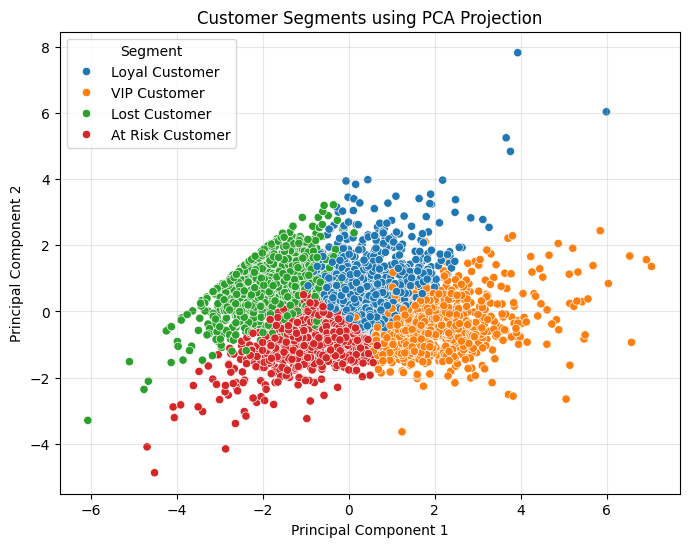

In [41]:
from sklearn.decomposition import PCA

# Reduce scaled features to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Store PCA components in the dataframe
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Visualize clusters in PCA space
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Segment"
)

plt.title("Customer Segments using PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
# Sauvegarder le dataset final
df.to_csv("../data/processed/customers_ML_segmented.csv", index=False)
df

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency,Average_Order_Value,Monetary_log,Frequency_log,AOV_log,Cluster,Segment,PCA1,PCA2
0,12346.0,1,77183.60,2011-01-18 10:01:00,325,77183.600000,11.253955,0.693147,11.253955,3,Loyal Customer,3.932160,7.813424
1,12347.0,7,4310.00,2011-12-07 15:52:00,1,615.714286,8.368925,2.079442,6.424406,0,VIP Customer,2.244037,0.139818
2,12348.0,4,1797.24,2011-09-25 13:13:00,74,449.310000,7.494564,1.609438,6.109936,3,Loyal Customer,0.978735,0.350955
3,12349.0,1,1757.55,2011-11-21 09:51:00,18,1757.550000,7.472245,0.693147,7.472245,3,Loyal Customer,1.226801,1.875976
4,12350.0,1,334.40,2011-02-02 16:01:00,309,334.400000,5.815324,0.693147,5.815324,2,Lost Customer,-1.674994,1.584893
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4333,18280.0,1,180.60,2011-03-07 09:52:00,277,180.600000,5.201806,0.693147,5.201806,2,Lost Customer,-2.185718,0.718321
4334,18281.0,1,80.82,2011-06-12 10:53:00,180,80.820000,4.404522,0.693147,4.404522,2,Lost Customer,-2.625879,-0.708698
4335,18282.0,2,178.05,2011-12-02 11:43:00,7,89.025000,5.187665,1.098612,4.500087,1,At Risk Customer,-1.172405,-1.658372
4336,18283.0,16,2045.53,2011-12-06 12:02:00,3,127.845625,7.623901,2.833213,4.858615,0,VIP Customer,1.595875,-1.900658
